In [121]:
# import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

In [122]:
# data download form the following
# https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
# # Path to the dataset directories
train_dir = r'C:\Users\abc\Desktop\Computer_vision\skin_dataset_resized\train_set'  # Change to your train folder path
validation_dir = r'C:\Users\abc\Desktop\Computer_vision\skin_dataset_resized\val_set'  # Change to your validation folder path

In [123]:
# 1. Data Preprocessing with ImageDataGenerator
# ImageDataGenerator is used for real-time image augmentation and rescaling pixel values.

train_datagen = ImageDataGenerator(rescale=1./255)  # Rescale images to [0, 1] without any augmentation (like rotation, shifting, etc.)
# 1./255 is simply dividing each pixel value by 255, which scales the pixel values to the range [0, 1]
# For example, if an original pixel value was 128, after rescaling it becomes 128/255 = 0.50196.
validation_datagen = ImageDataGenerator(rescale=1./255)  # Rescale images to [0, 1]

In [124]:
# 2. Flowing the Images from the Directory for Training
train_generator = train_datagen.flow_from_directory(
    train_dir,  # Path to the train directory
    target_size=(150, 150),  # Resize all images to 150x150 pixels
    batch_size=32,  # Number of images per batch
    class_mode='binary'  # Binary classification (cats vs dogs)
)
#If you were working with more than two classes, you would use class_mode='categorical'

Found 8000 images belonging to 2 classes.


In [127]:
# 3. Flowing the Images from the Directory for Validation
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,  # Path to the validation directory
    target_size=(150, 150),  # Resize images to 150x150 pixels
    batch_size=32,  # Number of images per batch
    class_mode='binary'  # Binary classification
)
#If you were working with more than two classes, you would use class_mode='categorical'

Found 1100 images belonging to 2 classes.


In [128]:
# 4. Define the CNN Model
# Sequential is a Keras model class that allows you to build a 
# neural network layer-by-layer in a straightforward, linear way.

# Model Initialization: model = Sequential() initializes an empty model. 
# After this, you can add layers to this model one at a time.
#Layer Stacking: Each layer you add will connect sequentially to 
# the previous one, which makes it easy to build simple models like CNNs.

model = Sequential()


# 5. Add the first Convolutional Layer

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
# Conv2D: 32 filters, each 3x3, with ReLU activation function
# input_shape: images are 150x150 pixels with 3 color channels (RGB)

model.add(MaxPooling2D(2, 2))  # MaxPooling2D: Reduce the spatial size by pooling 2x2 regions

# 6. Add the second Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))  # 64 filters with 3x3 kernels
model.add(MaxPooling2D(2, 2))  # Max pooling again

# 7. Add the third Convolutional Layer
model.add(Conv2D(128, (3, 3), activation='relu'))  # 128 filters with 3x3 kernels
model.add(MaxPooling2D(2, 2))  # Max pooling

# 8. Add the fourth Convolutional Layer
model.add(Conv2D(256, (3, 3), activation='relu'))  # 256 filters with 3x3 kernels
model.add(MaxPooling2D(2, 2))  # Max pooling

# 9. Add the Fifth Convolutional Layer
model.add(Conv2D(512, (3, 3), activation='relu'))  # 512 filters with 3x3 kernels
model.add(MaxPooling2D(2, 2))  # Max pooling

# 11. Flatten the feature maps
model.add(Flatten())  # Convert the 2D feature maps into a 1D vector

# 12. Add a Fully Connected Layer
model.add(Dense(128, activation='relu'))  # Fully connected layer with 128 neurons
model.add(Dropout(0.5))  # Dropout layer to prevent overfitting (50% chance of deactivating neurons)

# 13. Add the Output Layer
model.add(Dense(1, activation='sigmoid'))  # Output layer with 1 neuron, sigmoid for binary classification



In [129]:
# 11. Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
# Adam optimizer with a small learning rate (0.0001) for stable training
# Binary cross-entropy loss function is used for binary classification (cats vs dogs)



In [130]:
# Train the model and save training progress in "history"
# history = model.fit(train_data, epochs=10, validation_data=val_data, batch_size=32)

# his means the model will look at 32 images at a time from the training data before updating its weights. 


history = model.fit(
    train_generator,               # Use our training images (cats and dogs)
    epochs=1,                     # Train for 10 rounds over all training images
    validation_data=validation_generator  # Use validation images to check progress
)


c:\Users\abc\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 165s 631ms/step - accuracy: 0.6862 - loss: 0.5707 - val_accuracy: 0.8091 - val_loss: 0.4425


In [131]:
# 12. Checkpoint to Save Best Model
#checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=1)
# Save the model only if the validation loss improves during training

# 13. Train the Model
#history = model.fit(
#    train_generator,  # Training data
#    steps_per_epoch=train_generator.samples // train_generator.batch_size,  # Number of batches per epoch
#    epochs=10,  # Number of epochs (you can increase this)
#    validation_data=validation_generator,  # Validation data
#    validation_steps=validation_generator.samples // validation_generator.batch_size,  # Validation batches
#    callbacks=[checkpoint]  # Use the checkpoint callback to save the best model
#)


from tensorflow.keras.callbacks import ModelCheckpoint

# 12. Checkpoint to Save Best Model
checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', mode='min', verbose=1)

# 13. Train the Model
history = model.fit(
    train_generator,  # Training data
    steps_per_epoch=train_generator.samples // train_generator.batch_size,  # Number of batches per epoch
    epochs=15,  # Number of epochs (you can increase this)
    validation_data=validation_generator,  # Validation data
    validation_steps=validation_generator.samples // validation_generator.batch_size,  # Validation batches
    callbacks=[checkpoint]  # Use the checkpoint callback to save the best model
)


Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.8593 - loss: 0.3469
Epoch 1: val_loss improved from inf to 0.33520, saving model to best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 166s 661ms/step - accuracy: 0.8593 - loss: 0.3468 - val_accuracy: 0.8603 - val_loss: 0.3352
Epoch 2/15

Epoch 2: val_loss improved from 0.33520 to 0.20730, saving model to best_model.keras


c:\Users\abc\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8333 - val_loss: 0.2073
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8827 - loss: 0.2924
Epoch 3: val_loss did not improve from 0.20730
250/250 ━━━━━━━━━━━━━━━━━━━━ 1912s 8s/step - accuracy: 0.8827 - loss: 0.2924 - val_accuracy: 0.8474 - val_loss: 0.3739
Epoch 4/15

Epoch 4: val_loss did not improve from 0.20730
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.2889
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.8764 - loss: 0.2945
Epoch 5: val_loss did not improve from 0.20730
250/250 ━━━━━━━━━━━━━━━━━━━━ 174s 694ms/step - accuracy: 0.8764 - loss: 0.2945 - val_accuracy: 0.8787 - val_loss: 0.3093
Epoch 6/15

Epoch 6: val_loss did not improve from 0.20730
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9167 - val_loss: 0.3

In [132]:
# 
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 5, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,492,933 (20.95 MB)

 Trainable params: 1,830,977 (6.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,661,956 (13.97 MB)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


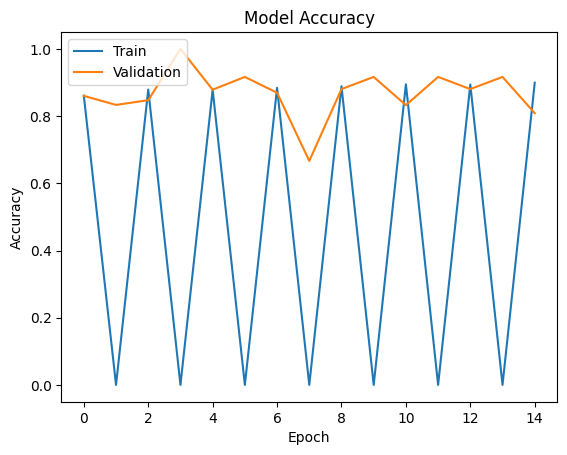

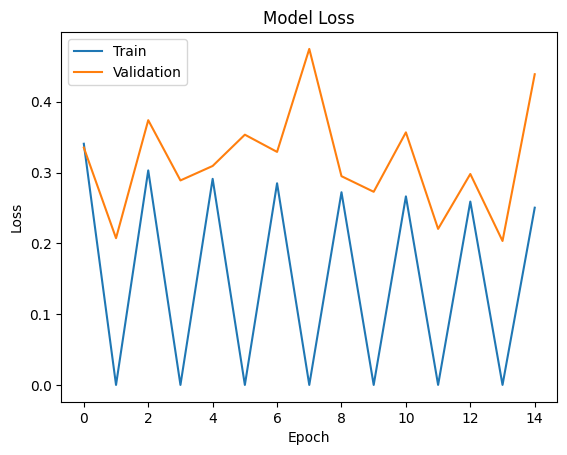

In [133]:
import matplotlib.pyplot as plt
%matplotlib inline

# Assuming 'history' is the result of model training (e.g., history = model.fit(...))
print(history.history.keys())  # Listing all training data keys

# Plotting accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [134]:

# 14. Save the Final Model
model.save('Skin_CancerDataset_cnn_model.h5')  # Save the final model


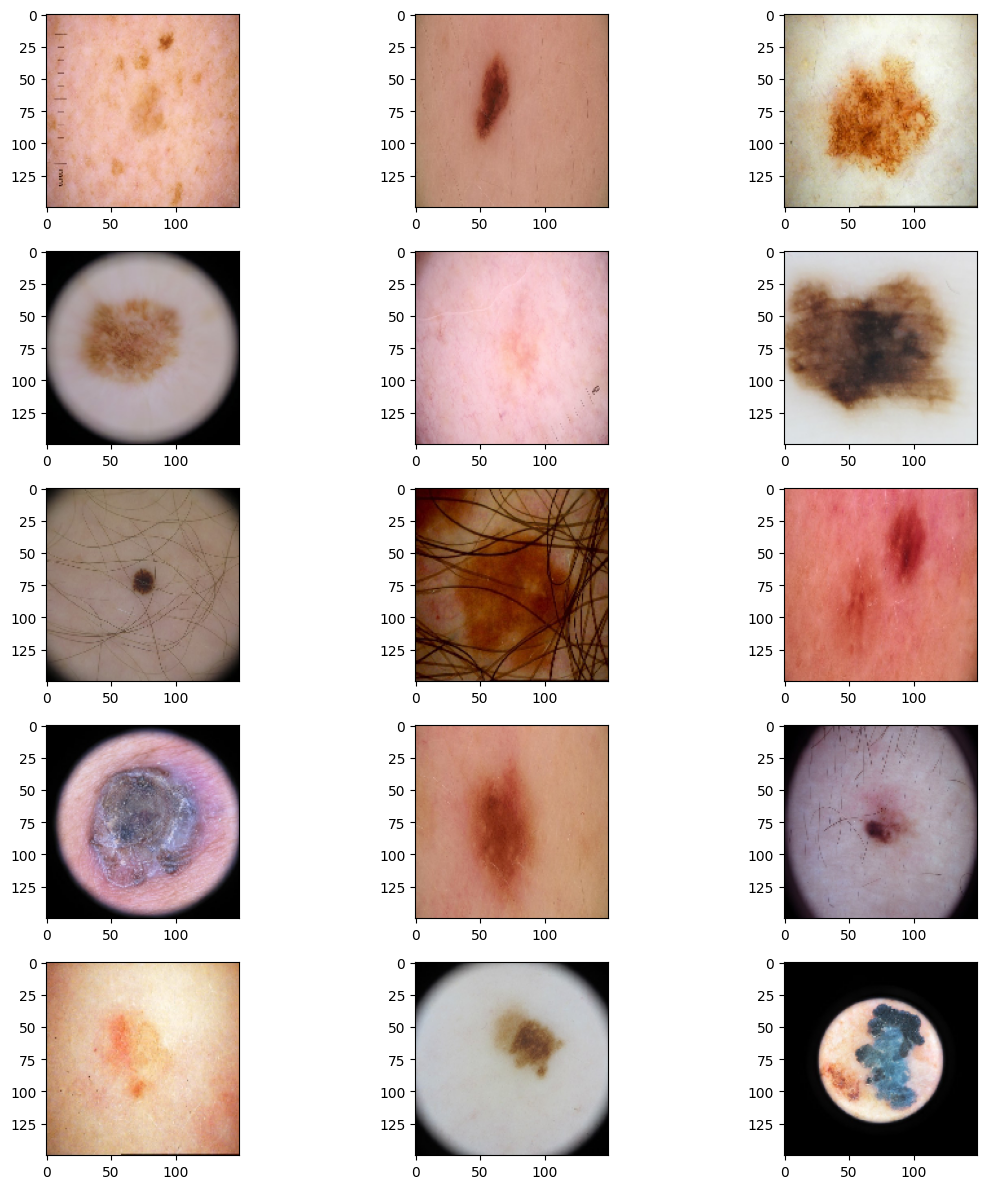

In [135]:
plt.figure(figsize=(12,12))
for i in range (0,15):
  plt.subplot(5,3,i+1)
  for X_batch, Y_batch in train_generator:
    image = X_batch[0]
    plt.imshow(image)
    break

plt.tight_layout()
plt.show()

In [145]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the image you want to test
img_path = r'C:\Users\abc\Desktop\Computer_vision\skin_dataset_resized\train_set\malignant\ISIC_0031013_640x480.jpg'  # Replace with the path to your image
img = image.load_img(img_path, target_size=(150, 150))  # Resize to 150x150 (same as training)

# Image Loading: We load the image and resize it to the 
# same dimensions (150x150) used during training.




In [146]:
#Convert and Scale: The image is converted to an array, 
# and pixel values are scaled to match the training range (0–1).
# Convert the image to an array and scale it
img_array = image.img_to_array(img) / 255.0  # Scale pixel values to [0, 1]

# # image.img_to_array(img): This function converts the loaded image into a NumPy array of pixel values. 
# By default, pixel values in images range from 0 to 255 for each color channel (Red, Green, and Blue).
# Why Add an Extra Dimension?: Without this extra dimension, the shape of img_array 
# would be (150, 150, 3), but the model expects shape (1, 150, 150, 3) — the 1 here represents a batch of one image.

img_array = np.expand_dims(img_array, axis=0)  # Add an extra dimension for batch (1, 150, 150, 3)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
It's a malignant!
Confidence: 0.71


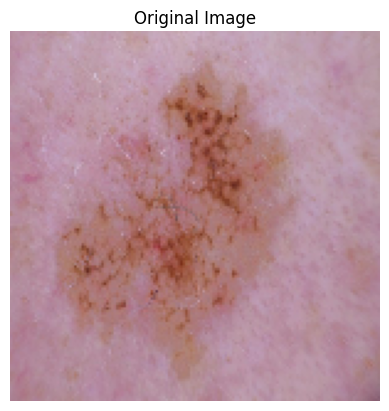

In [150]:
import matplotlib.pyplot as plt # Matplotlib for visualization
# Predict the class of the image
prediction = model.predict(img_array)

# Check the prediction result
if prediction[0][0] > 0.7:
    print("It's a malignant!")
else:
    print("It's a benign!")
print(f"Confidence: {prediction[0][0]:.2f}")

plt.imshow(img)  # Matplotlib works with RGB images directly
plt.title("Original Image")
plt.axis("off")  # Hide axis for cleaner display
plt.show()